In [2]:
import os
import pandas as pd
from pathlib import Path

# === CONFIGURATION ===
OUTPUT_FILE = "deep_scan_report.txt"
ROOT_DIR = Path.cwd()

# Files to PEEK into (Read columns/head)
DATA_EXTENSIONS = {'.csv', '.tsv', '.xlsx', '.parquet', '.txt'}
# Files to just LOG existence/size (Models, binaries)
BINARY_EXTENSIONS = {'.pt', '.pth', '.pkl', '.h5', '.onnx', '.gml', '.graphml'}
# Code files (to map structure)
CODE_EXTENSIONS = {'.py', '.ipynb', '.json', '.yaml'}

# Folders to ignore completely
IGNORE_DIRS = {'.git', '__pycache__', '.ipynb_checkpoints', 'venv', 'env', 'node_modules', 'wandb'}

def get_file_info(path):
    """Returns size in human readable format"""
    try:
        size = path.stat().st_size
        for unit in ['B', 'KB', 'MB', 'GB']:
            if size < 1024:
                return f"{size:.2f} {unit}"
            size /= 1024
        return f"{size:.2f} TB"
    except Exception:
        return "Unknown"

def peek_data_file(path):
    """Tries to read the header/columns of data files."""
    try:
        if path.suffix == '.csv':
            df = pd.read_csv(path, nrows=2)
            return f"[CSV STRUCTURE]\nColumns: {list(df.columns)}\nShape (preview): {df.shape}"
        elif path.suffix == '.tsv':
            df = pd.read_csv(path, sep='\t', nrows=2)
            return f"[TSV STRUCTURE]\nColumns: {list(df.columns)}\nShape (preview): {df.shape}"
        elif path.suffix == '.parquet':
            df = pd.read_parquet(path)
            # Just columns for parquet as reading rows might be heavy
            return f"[PARQUET STRUCTURE]\nColumns: {list(df.columns)}\nFull Shape: {df.shape}"
        elif path.suffix == '.xlsx':
            df = pd.read_excel(path, nrows=2)
            return f"[EXCEL STRUCTURE]\nColumns: {list(df.columns)}"
        elif path.suffix == '.txt':
            with open(path, 'r', encoding='utf-8', errors='ignore') as f:
                head = [next(f).strip() for _ in range(5)]
            return f"[TXT PREVIEW]\n" + "\n".join(head)
    except Exception as e:
        return f"[ERROR READING DATA]: {e}"
    return ""

def main():
    report = []
    report.append(f"=== DEEP SCAN REPORT ===")
    report.append(f"Root: {ROOT_DIR}\n")
    
    print(f"🚀 Starting Deep Scan of {ROOT_DIR}...")
    
    file_count = 0
    found_target_csv = False
    found_model = False

    for root, dirs, files in os.walk(ROOT_DIR):
        # Filter directories in-place
        dirs[:] = [d for d in dirs if d not in IGNORE_DIRS]
        
        current_path = Path(root)
        rel_path = current_path.relative_to(ROOT_DIR)
        
        if str(rel_path) == ".":
            report.append(f"\n📂 [ROOT] {ROOT_DIR}")
        else:
            report.append(f"\n📂 /{rel_path}")

        for file in files:
            file_path = current_path / file
            file_size = get_file_info(file_path)
            ext = file_path.suffix.lower()
            
            # Header log
            report.append(f"   📄 {file}  ({file_size})")
            
            # 1. PEEK DATA FILES
            if ext in DATA_EXTENSIONS:
                content_preview = peek_data_file(file_path)
                if content_preview:
                    report.append(f"      {content_preview.replace(chr(10), chr(10)+'      ')}")
                
                # Check specific targets
                if file == "master_connectome_dataset.csv":
                    found_target_csv = True
                    report.append(f"      🌟 TARGET FOUND: master_connectome_dataset.csv here!")

            # 2. LOG MODEL FILES
            elif ext in BINARY_EXTENSIONS:
                report.append(f"      🤖 [MODEL/BINARY FILE]")
                if "gnca" in file or "model" in file:
                    found_model = True
                    report.append(f"      🌟 POTENTIAL NCA MODEL")

            file_count += 1

    report_content = "\n".join(report)
    
    with open(OUTPUT_FILE, 'w', encoding='utf-8') as f:
        f.write(report_content)
        
    print(f"✅ Scan Complete. Scanned {file_count} files.")
    print(f"📄 Report saved to: {OUTPUT_FILE}")
    
    if not found_target_csv:
        print("⚠️  WARNING: Could not find 'master_connectome_dataset.csv' anywhere in the tree.")
    else:
        print("✅ Found 'master_connectome_dataset.csv'.")

if __name__ == "__main__":
    main()

🚀 Starting Deep Scan of /mnt/ssd4tb/Desktop/C-Elegans...
✅ Scan Complete. Scanned 2173 files.
📄 Report saved to: deep_scan_report.txt
⚠️  WARNING: Could not find 'master_connectome_dataset.csv' anywhere in the tree.


In [3]:
# run_nca_pipeline.py
# Fully integrated NCA Pipeline (Cells 1-G)
# Tailored for environment: /home/rohit/Desktop/C-Elegans

import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from scipy.stats import pearsonr
from copy import deepcopy

# ==============================================================================
# Cell 1 — Setup & load data
# ==============================================================================
print("=== Cell 1: Setup & Load Data ===")

ROOT = Path("/home/rohit/Desktop/C-Elegans")
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
EXPERIMENTS_OUT = DATA_PROCESSED / "experiments"
EXPERIMENTS_OUT.mkdir(parents=True, exist_ok=True)

# Load expression (neurons x genes, columns are WBGene IDs)
expr_path = DATA_PROCESSED / "csv" / "gene_expr_CeNGEN_base_mapped.csv"
if not expr_path.exists():
    raise FileNotFoundError(f"Expression file not found at {expr_path}")
expr_df = pd.read_csv(expr_path, index_col=0)

# Load connectome edges (Source, Target, SynapseCount)
edges_path = DATA_PROCESSED / "csv" / "merged_edges_with_relatedness.csv"
if not edges_path.exists():
    # Fallback to master connectome if merged edges missing
    edges_path = ROOT / "master_connectome_dataset.csv"
    if not edges_path.exists():
         raise FileNotFoundError(f"Edges file not found at {edges_path}")

edges_df = pd.read_csv(edges_path)
edges_df.columns = [c.lower() for c in edges_df.columns]

# Resolve columns dynamically
src_col = [c for c in edges_df.columns if "source" in c][0]
tgt_col = [c for c in edges_df.columns if "target" in c][0]
w_col   = "synapsecount" if "synapsecount" in edges_df.columns else "weight"
if w_col not in edges_df.columns:
    w_col = None

print(f"expr_df: {expr_df.shape}; edges: {edges_df.shape}; weight_col: {w_col}")

# ==============================================================================
# Cell 2 — Graph, features, and targets
# ==============================================================================
print("\n=== Cell 2: Feature Engineering ===")

# Keep only neurons present in expression
neurons = expr_df.index.tolist()
neuron_to_idx = {n:i for i,n in enumerate(neurons)}
N = len(neurons)

# Build (directed) adjacency list from edges; drop edges where nodes not in expr_df
mask_src = edges_df[src_col].isin(neurons)
mask_tgt = edges_df[tgt_col].isin(neurons)
Edf = edges_df[mask_src & mask_tgt].copy()

# Edge weights
if w_col is None:
    Edf["w"] = 1.0
else:
    Edf["w"] = Edf[w_col].astype(float).clip(lower=0.0)

# Sparse adjacency in COO form
rows = Edf[src_col].map(neuron_to_idx).values
cols = Edf[tgt_col].map(neuron_to_idx).values
wts  = Edf["w"].values.astype(np.float32)

# Target: mean outgoing synaptic strength per neuron (normalize)
out_w = Edf.groupby(src_col)["w"].mean().reindex(neurons).fillna(0.0).values.astype(np.float32)
y = (out_w - out_w.mean()) / (out_w.std() + 1e-6)  # z-score target

# ==== Features ====
USE_PCA = True        # set False to use raw subset of genes
N_PCA   = 32          # PCA dims if USE_PCA=True
RAW_K   = 512         # top-variance genes if USE_PCA=False

if USE_PCA:
    scaler = StandardScaler(with_mean=True, with_std=True)
    X_scaled = scaler.fit_transform(expr_df.values)         # (N x G)
    pca = PCA(n_components=min(N_PCA, X_scaled.shape[1]), random_state=42)
    X_feat = pca.fit_transform(X_scaled).astype(np.float32) # (N x d)
else:
    # raw features: top-variance genes
    top_genes = expr_df.var(axis=0).sort_values(ascending=False).head(RAW_K).index
    X_feat = expr_df.loc[:, top_genes].fillna(0.0).values.astype(np.float32)
    # z-score per feature
    X_feat = (X_feat - X_feat.mean(0)) / (X_feat.std(0) + 1e-6)

print(f"N={N}, edges kept={len(rows)}, features={X_feat.shape}, target y shape={y.shape}")

# ==============================================================================
# Cell 3 — Graph Neural Cellular Automata (GNCA) Definition
# ==============================================================================
print("\n=== Cell 3: Defining GNCA Model ===")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Convert arrays to torch
X_feat_t = torch.from_numpy(X_feat).to(device)              # (N, d_in)
y_t       = torch.from_numpy(y).to(device)                  # (N,)

# Build sparse adjacency (row-normalized for message passing)
indices = torch.stack([
    torch.from_numpy(rows).long(),
    torch.from_numpy(cols).long()
], dim=0).to(device)
values  = torch.from_numpy(wts).to(device)
A = torch.sparse_coo_tensor(indices, values, size=(N, N)).coalesce()

# Row-normalize A
row_sum = torch.sparse.sum(A, dim=1).to_dense().clamp_min(1e-6)  # (N,)
row_inv = 1.0 / row_sum
row_inv_diag = torch.sparse_coo_tensor(
    torch.stack([torch.arange(N), torch.arange(N)]).to(device),
    row_inv, size=(N, N)
).coalesce()
A_norm = torch.sparse.mm(row_inv_diag, A).coalesce()  # normalized by out-degree weight sum

class GNCA(nn.Module):
    def __init__(self, in_dim, state_dim=64, fire_rate=0.5):
        super().__init__()
        self.state_dim  = state_dim
        self.fire_rate  = fire_rate
        # init embed from features to state
        self.inp = nn.Linear(in_dim, state_dim)
        # message and update (residual)
        self.msg = nn.Linear(state_dim, state_dim, bias=False)
        self.upd = nn.Sequential(
            nn.Linear(2*state_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, state_dim)
        )
        # readout head to scalar
        self.readout = nn.Sequential(
            nn.LayerNorm(state_dim),
            nn.Linear(state_dim, 1)
        )

    def forward(self, x_feat, A_norm, steps=8, train_mode=True):
        # initialize state from features
        x = torch.tanh(self.inp(x_feat))   # (N, C)
        for t in range(steps):
            # messages from neighbors: A_norm @ msg(x)
            m = torch.sparse.mm(A_norm, self.msg(x))
            # concat self-state and neighbor-message
            z = torch.cat([x, m], dim=-1)
            dx = self.upd(z)
            # stochastic "fire" mask for asynch updates
            if train_mode and self.fire_rate < 1.0:
                mask = (torch.rand_like(dx[:, :1]) < self.fire_rate).float()
                dx = dx * mask
            # residual update
            x = x + dx
        # readout scalar per node
        yhat = self.readout(x).squeeze(-1)
        return yhat, x

model = GNCA(in_dim=X_feat_t.shape[1], state_dim=64, fire_rate=0.5).to(device)
print(f"Model Parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

# ==============================================================================
# Cell 4 — Train GNCA (Outgoing Strength Prediction)
# ==============================================================================
print("\n=== Cell 4: Training GNCA (Synaptic Strength) ===")

torch.manual_seed(42)
optim = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=200, eta_min=3e-4)
loss_fn = nn.MSELoss()

EPOCHS = 200
STEPS  = 8  # unroll steps

best = math.inf
for ep in range(1, EPOCHS+1):
    model.train()
    yhat, _ = model(X_feat_t, A_norm, steps=STEPS, train_mode=True)
    loss = loss_fn(yhat, y_t)
    optim.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optim.step()
    sched.step()

    if loss.item() < best:
        best = loss.item()
        torch.save(model.state_dict(), EXPERIMENTS_OUT / "gnca_best.pt")

    if ep % 20 == 0 or ep == 1:
        with torch.no_grad():
            ycpu = y_t.detach().cpu().numpy()
            phat = yhat.detach().cpu().numpy()
            r = np.corrcoef(ycpu, phat)[0,1]
        print(f"Epoch {ep:03d} | loss={loss.item():.4f} | r={r:.3f}")

print("Best loss:", best)

# ==============================================================================
# Cell 5 — Final eval & export
# ==============================================================================
print("\n=== Cell 5: Evaluation & Export ===")

model.load_state_dict(torch.load(EXPERIMENTS_OUT / "gnca_best.pt", map_location=device))
model.eval()
with torch.no_grad():
    yhat, X_final = model(X_feat_t, A_norm, steps=8, train_mode=False)
    yhat = yhat.detach().cpu().numpy()
    ytrue = y_t.detach().cpu().numpy()
    r = np.corrcoef(ytrue, yhat)[0,1]
    mae = np.abs(ytrue - yhat).mean()
print(f"Final Pearson r={r:.3f} | MAE={mae:.3f}")

pred_df = pd.DataFrame({
    "neuron": neurons,
    "y_true_z": ytrue,
    "y_pred_z": yhat
})
pred_path = EXPERIMENTS_OUT / "gnca_pred_outgoing_strength.csv"
pred_df.to_csv(pred_path, index=False)
print("Saved:", pred_path)

# ==============================================================================
# Cell A — Shuffle control
# ==============================================================================
print("\n=== Cell A: Shuffle Control ===")
torch.manual_seed(123)

perm = torch.randperm(X_feat_t.shape[0], device=X_feat_t.device)
X_feat_shuf = X_feat_t[perm]  # break neuron-expression alignment

model_shuf = GNCA(in_dim=X_feat_t.shape[1], state_dim=64, fire_rate=0.5).to(device)
opt = torch.optim.AdamW(model_shuf.parameters(), lr=3e-3, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=80, eta_min=5e-4)
loss_fn = torch.nn.MSELoss()

EPOCHS_SHUF = 80
for ep in range(1, EPOCHS_SHUF+1):
    model_shuf.train()
    yhat, _ = model_shuf(X_feat_shuf, A_norm, steps=8, train_mode=True)
    loss = loss_fn(yhat, y_t)
    opt.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(model_shuf.parameters(), 1.0); opt.step(); sch.step()
    if ep % 20 == 0 or ep == 1:
        with torch.no_grad():
            r = np.corrcoef(y_t.detach().cpu().numpy(), yhat.detach().cpu().numpy())[0,1]
        print(f"[SHUF] Epoch {ep:03d} | loss={loss.item():.4f} | r={r:.3f}")

# ==============================================================================
# Cell B — Edge dropout experiment
# ==============================================================================
print("\n=== Cell B: Edge Dropout Experiment ===")

drop_rate = 0.5
vals = A_norm.values()
mask = (torch.rand_like(vals) > drop_rate).float()
A_drop = torch.sparse_coo_tensor(A_norm.indices(), vals * mask, A_norm.size()).coalesce()

model_small = GNCA(in_dim=X_feat_t.shape[1], state_dim=8, fire_rate=0.5).to(device)
opt = torch.optim.AdamW(model_small.parameters(), lr=3e-3, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=120, eta_min=5e-4)
loss_fn = torch.nn.MSELoss()

EPOCHS_DROP = 120
for ep in range(1, EPOCHS_DROP+1):
    model_small.train()
    yhat, _ = model_small(X_feat_t, A_drop, steps=8, train_mode=True)
    loss = loss_fn(yhat, y_t)
    opt.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(model_small.parameters(), 1.0); opt.step(); sch.step()
    if ep % 20 == 0 or ep == 1:
        with torch.no_grad():
            r = np.corrcoef(y_t.detach().cpu().numpy(), yhat.detach().cpu().numpy())[0,1]
        print(f"[DROP{int(drop_rate*100)}%|d=8] Epoch {ep:03d} | loss={loss.item():.4f} | r={r:.3f}")

# ==============================================================================
# Cell C — Saliency and Integrated Gradients (IG)
# ==============================================================================
print("\n=== Cell C: Feature Importance (Saliency & IG) ===")

model.eval()

def predict_from_input(x, steps=8):
    yhat, _ = model(x, A_norm, steps=steps, train_mode=False)
    return yhat

# --- Saliency ---
X_feat_t.requires_grad_(True)
yhat = predict_from_input(X_feat_t, steps=8)
obj = yhat.sum()
model.zero_grad()
if X_feat_t.grad is not None: X_feat_t.grad.zero_()
obj.backward(retain_graph=True)

sal = X_feat_t.grad.detach().abs().mean(dim=0).cpu().numpy()
sal_df = pd.DataFrame({"feature_idx": np.arange(len(sal)), "saliency": sal}).sort_values("saliency", ascending=False)
sal_path = EXPERIMENTS_OUT / "gnca_saliency_features.csv"
sal_df.to_csv(sal_path, index=False)
print("Saved saliency →", sal_path)
X_feat_t.requires_grad_(False)

# --- Integrated Gradients ---
def integrated_gradients(x, steps=32):
    baseline = torch.zeros_like(x)
    grads_accum = torch.zeros_like(x)
    for a in torch.linspace(0, 1, steps, device=x.device):
        x_a = baseline + a * (x - baseline)
        x_a.requires_grad_(True)
        y_a = predict_from_input(x_a, steps=8).sum()
        model.zero_grad()
        if x_a.grad is not None: x_a.grad.zero_()
        y_a.backward()
        grads_accum += x_a.grad
    ig = (x - baseline) * (grads_accum / steps)
    return ig

with torch.no_grad():
    pass 

ig = integrated_gradients(X_feat_t, steps=32)
ig_feat = ig.detach().cpu().numpy().mean(axis=0)
ig_df = pd.DataFrame({"feature_idx": np.arange(len(ig_feat)), "IG": ig_feat}).sort_values("IG", ascending=False)
ig_path = EXPERIMENTS_OUT / "gnca_integrated_gradients_features.csv"
ig_df.to_csv(ig_path, index=False)
print("Saved IG →", ig_path)

# ==============================================================================
# Cell D — Graph-only vs Expression-only Baselines
# ==============================================================================
print("\n=== Cell D: Baselines ===")

def train_gnca_baseline(X_in, A_in, label, name, steps=8, state_dim=64, epochs=100):
    model_b = GNCA(in_dim=X_in.shape[1], state_dim=state_dim, fire_rate=0.5).to(device)
    opt = torch.optim.AdamW(model_b.parameters(), lr=3e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=5e-4)
    loss_fn = nn.MSELoss()
    best_r = 0
    for ep in range(1, epochs+1):
        model_b.train()
        yhat, _ = model_b(X_in, A_in, steps=steps, train_mode=True)
        loss = loss_fn(yhat, label)
        opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model_b.parameters(),1.0); opt.step(); sch.step()
        if ep % 20 == 0 or ep == 1:
            with torch.no_grad():
                r = np.corrcoef(label.detach().cpu().numpy(), yhat.detach().cpu().numpy())[0,1]
            print(f"[{name}] Epoch {ep:03d} | loss={loss.item():.4f} | r={r:.3f}")
            best_r = r
    return best_r

# Graph-only
X_const = torch.ones_like(X_feat_t)
r_graph = train_gnca_baseline(X_const, A_norm, y_t, "GRAPH-ONLY")

# Expr-only (Dense Adjacency)
N = X_feat_t.shape[0]
dense_vals = torch.ones(N*N, device=device)
dense_idx  = torch.stack([torch.arange(N).repeat_interleave(N),
                          torch.arange(N).repeat(N)]).to(device)
A_dense = torch.sparse_coo_tensor(dense_idx, dense_vals, size=(N,N)).coalesce()
# Norm
row_sum = torch.sparse.sum(A_dense, dim=1).to_dense().clamp_min(1e-6)
row_inv = 1.0 / row_sum
diag_idx = torch.stack([torch.arange(N), torch.arange(N)]).to(device)
A_dense_norm = torch.sparse_coo_tensor(diag_idx, row_inv, (N,N)).coalesce()
A_dense_norm = torch.sparse.mm(A_dense_norm, A_dense).coalesce()

r_expr = train_gnca_baseline(X_feat_t, A_dense_norm, y_t, "EXPR-ONLY")

print("\n=== Baseline Comparison ===")
print(f"Graph-only r = {r_graph:.3f}")
print(f"Expression-only r = {r_expr:.3f}")


# ==============================================================================
# Cell D-prep — Rebuild Motif Matrix
# ==============================================================================
print("\n=== Cell D-prep: Rebuilding Motif Matrix ===")
# Note: Using the paths defined at start
motif_out = DATA_PROCESSED / "motifs" / "motif_matrix.csv"
motif_out.parent.mkdir(parents=True, exist_ok=True)

# Build Graph from Edges
G = nx.DiGraph()
for _, r in edges_df.iterrows():
    # Handle column names being lowercase from earlier
    s = r[src_col] if src_col in r else r["Source"]
    t = r[tgt_col] if tgt_col in r else r["Target"]
    G.add_edge(s, t)

print(f"Graph built: {G.number_of_nodes()} neurons, {G.number_of_edges()} synapses")

motif_names = ["reciprocal", "chain", "feedforward", "divergent", "convergent"]
motif_participation = {n: np.zeros(len(motif_names), dtype=int) for n in G.nodes()}

nodes = list(G.nodes())
for i, a in enumerate(tqdm(nodes, desc="Scanning motifs")):
    for b in G.successors(a):
        # reciprocal
        if G.has_edge(b, a):
            motif_participation[a][0] = 1
            motif_participation[b][0] = 1
        # divergent (A→B, A→C)
        for c in G.successors(a):
            if b != c:
                motif_participation[a][3] = 1
                motif_participation[b][4] = 1
                motif_participation[c][4] = 1
                # feedforward (A→B, A→C, B→C)
                if G.has_edge(b, c):
                    motif_participation[a][2] = 1
                    motif_participation[b][1] = 1
                    motif_participation[c][4] = 1
        # chain (A→B→C)
        for c in G.successors(b):
            if c != a:
                motif_participation[a][1] = 1
                motif_participation[b][1] = 1
                motif_participation[c][1] = 1

motif_df = pd.DataFrame.from_dict(motif_participation, orient="index", columns=motif_names)
motif_df.index.name = "Neuron"
# Normalize (binary participation)
motif_df = (motif_df > 0).astype(int)
motif_df.to_csv(motif_out)
print(f"✅ Saved motif matrix → {motif_out}")


# ==============================================================================
# Cell E — GNCA for Motif Prediction
# ==============================================================================
print("\n=== Cell E: GNCA Motif Prediction ===")

# Align Expression & Motifs
# 1. Clean IDs
expr_df.index = expr_df.index.astype(str).str.strip().str.upper()
motif_df.index = motif_df.index.astype(str).str.strip().str.upper()

# 2. Intersection
common_neurons = sorted(set(expr_df.index) & set(motif_df.index))
print(f"✅ Common neurons: {len(common_neurons)}")

expr_df_aligned = expr_df.reindex(common_neurons).dropna()
motif_df_aligned = motif_df.reindex(common_neurons).dropna()

# 3. Build Tensors
X_motif = StandardScaler().fit_transform(expr_df_aligned.values)
y_motif = motif_df_aligned.values.astype(np.float32)

X_m = torch.tensor(X_motif, dtype=torch.float32).to(device)
y_m = torch.tensor(y_motif, dtype=torch.float32).to(device)

# 4. Build Symmetric Adjacency for Motif Model
neuron_index = {n: i for i, n in enumerate(common_neurons)}
N_m = len(common_neurons)
A_m = torch.zeros((N_m, N_m), dtype=torch.float32)

# Use original edges to fill A_m
# Need to ensure uppercase matching
edges_df[src_col] = edges_df[src_col].astype(str).str.strip().str.upper()
edges_df[tgt_col] = edges_df[tgt_col].astype(str).str.strip().str.upper()

for _, row in edges_df.iterrows():
    s, t = row[src_col], row[tgt_col]
    if s in neuron_index and t in neuron_index:
        i, j = neuron_index[s], neuron_index[t]
        A_m[i, j] = A_m[j, i] = 1.0

A_m = A_m.to(device)

# 5. Define Motif GNCA Class (matches Cell E definition)
class GNCA_Motif(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, steps=3, dropout=0.3):
        super().__init__()
        self.fc_in = nn.Linear(in_dim, hidden_dim)
        self.fc_msg = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, out_dim)
        self.steps = steps
        self.dropout = nn.Dropout(dropout)

    def forward(self, X, A):
        h = F.relu(self.fc_in(X))
        for _ in range(self.steps):
            msg = self.fc_msg(self.dropout(h))
            # Normalized aggregation
            denom = A.sum(1, keepdim=True) + 1
            h = h + torch.matmul(A, msg) / denom
            h = F.relu(h)
        return torch.sigmoid(self.fc_out(h))

# 6. Train
model_motif = GNCA_Motif(in_dim=X_m.shape[1], hidden_dim=64, out_dim=y_m.shape[1], steps=3, dropout=0.3).to(device)
opt_m = torch.optim.Adam(model_motif.parameters(), lr=1e-3)
loss_fn_m = nn.BCELoss()

best_loss, best_r_m = np.inf, 0
for epoch in range(1, 201):
    model_motif.train()
    pred = model_motif(X_m, A_m)
    loss = loss_fn_m(pred, y_m)
    opt_m.zero_grad(); loss.backward(); opt_m.step()

    if epoch % 20 == 0 or epoch == 1:
        model_motif.eval()
        with torch.no_grad():
            r = np.corrcoef(pred.flatten().cpu(), y_m.flatten().cpu())[0, 1]
        print(f"Epoch {epoch:03d} | loss={loss.item():.4f} | r={r:.3f}")
        if loss.item() < best_loss:
            best_loss, best_r_m = loss.item(), r
            torch.save(model_motif.state_dict(), EXPERIMENTS_OUT / "gnca_motif_best.pt")

print(f"\n✅ Training complete | Best loss={best_loss:.6f} | Final Pearson r={best_r_m:.3f}")

# ==============================================================================
# Cell F — Visualization & Interpretation
# ==============================================================================
print("\n=== Cell F: Motif Model Interpretation ===")

model_motif.load_state_dict(torch.load(EXPERIMENTS_OUT / "gnca_motif_best.pt", map_location=device))
model_motif.eval()

with torch.no_grad():
    y_pred = model_motif(X_m, A_m).cpu().numpy()
    y_true = y_m.cpu().numpy()

motif_names = list(motif_df.columns)

# Metrics
perf = []
for i, motif in enumerate(motif_names):
    r, _ = pearsonr(y_true[:, i], y_pred[:, i])
    mae = np.mean(np.abs(y_true[:, i] - y_pred[:, i]))
    perf.append((motif, r, mae))

perf_df = pd.DataFrame(perf, columns=["motif", "pearson_r", "mae"])
perf_df.to_csv(EXPERIMENTS_OUT / "gnca_motif_performance.csv", index=False)
display_cols = ["motif", "pearson_r", "mae"]
print(perf_df[display_cols])

# Saliency (Motif Model)
X_m.requires_grad = True
model_motif.eval()
pred_mean = model_motif(X_m, A_m).mean()
pred_mean.backward()

saliency = X_m.grad.abs().mean(0).cpu().numpy()
sal_df_m = pd.DataFrame({
    "gene": expr_df_aligned.columns,
    "saliency": saliency
}).sort_values("saliency", ascending=False)

sal_df_m.to_csv(EXPERIMENTS_OUT / "gnca_saliency_genes.csv", index=False)
print("✅ Saved GNCA saliency scores → gnca_saliency_genes.csv")
print(sal_df_m.head(10))

# IG (Motif Model)
def integrated_gradients_motif(model, X, A, baseline=None, steps=50):
    if baseline is None:
        baseline = torch.zeros_like(X)
    scaled_inputs = [baseline + (float(i)/steps) * (X - baseline) for i in range(steps + 1)]
    grads = []
    for inp in scaled_inputs:
        inp = inp.detach().clone().requires_grad_()
        out = model(inp, A).mean()
        out.backward()
        grads.append(inp.grad.detach().clone())
    grads = torch.stack(grads).mean(0)
    IG = ((X - baseline) * grads).mean(0).detach().cpu().numpy()
    return IG

# Reset grads
model_motif.zero_grad()
if X_m.grad is not None: X_m.grad.zero_()

IG = integrated_gradients_motif(model_motif, X_m, A_m)
ig_df = pd.DataFrame({"gene": expr_df_aligned.columns, "integrated_gradients": IG})
ig_df = ig_df.sort_values("integrated_gradients", ascending=False)
ig_df.to_csv(EXPERIMENTS_OUT / "gnca_integrated_gradients_genes.csv", index=False)
print("✅ Saved integrated gradients → gnca_integrated_gradients_genes.csv")
print(ig_df.head(10))

print("\n🎉 Pipeline Execution Complete.")

=== Cell 1: Setup & Load Data ===
expr_df: (838, 22469); edges: (27727, 6); weight_col: synapsecount

=== Cell 2: Feature Engineering ===
N=838, edges kept=16673, features=(838, 32), target y shape=(838,)

=== Cell 3: Defining GNCA Model ===
device: cuda
Model Parameters: 0.03M

=== Cell 4: Training GNCA (Synaptic Strength) ===
Epoch 001 | loss=1.2283 | r=0.020
Epoch 020 | loss=0.1835 | r=0.904
Epoch 040 | loss=0.0993 | r=0.950
Epoch 060 | loss=0.0599 | r=0.970
Epoch 080 | loss=0.0814 | r=0.970
Epoch 100 | loss=0.0486 | r=0.979
Epoch 120 | loss=0.0351 | r=0.983
Epoch 140 | loss=0.0306 | r=0.985
Epoch 160 | loss=0.0297 | r=0.985
Epoch 180 | loss=0.0223 | r=0.989
Epoch 200 | loss=0.0241 | r=0.988
Best loss: 0.019428744912147522

=== Cell 5: Evaluation & Export ===
Final Pearson r=0.984 | MAE=0.110
Saved: /mnt/ssd4tb/Desktop/C-Elegans/data/processed/experiments/gnca_pred_outgoing_strength.csv

=== Cell A: Shuffle Control ===
[SHUF] Epoch 001 | loss=1.1639 | r=0.084


/tmp/ipykernel_218610/466468063.py:221: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(EXPERIMENTS_OUT / "gnca_best.pt", map_location=device)

[SHUF] Epoch 020 | loss=0.2437 | r=0.872
[SHUF] Epoch 040 | loss=0.1874 | r=0.901
[SHUF] Epoch 060 | loss=0.1509 | r=0.922
[SHUF] Epoch 080 | loss=0.1296 | r=0.934

=== Cell B: Edge Dropout Experiment ===
[DROP50%|d=8] Epoch 001 | loss=1.3559 | r=-0.054
[DROP50%|d=8] Epoch 020 | loss=0.4193 | r=0.766
[DROP50%|d=8] Epoch 040 | loss=0.3605 | r=0.800
[DROP50%|d=8] Epoch 060 | loss=0.3012 | r=0.837
[DROP50%|d=8] Epoch 080 | loss=0.2832 | r=0.847
[DROP50%|d=8] Epoch 100 | loss=0.2534 | r=0.865
[DROP50%|d=8] Epoch 120 | loss=0.2368 | r=0.874

=== Cell C: Feature Importance (Saliency & IG) ===
Saved saliency → /mnt/ssd4tb/Desktop/C-Elegans/data/processed/experiments/gnca_saliency_features.csv
Saved IG → /mnt/ssd4tb/Desktop/C-Elegans/data/processed/experiments/gnca_integrated_gradients_features.csv

=== Cell D: Baselines ===
[GRAPH-ONLY] Epoch 001 | loss=2.0611 | r=-0.022
[GRAPH-ONLY] Epoch 020 | loss=0.2995 | r=0.854
[GRAPH-ONLY] Epoch 040 | loss=0.2557 | r=0.863
[GRAPH-ONLY] Epoch 060 | loss

Scanning motifs: 100%|██████████| 1533/1533 [00:00<00:00, 12734.43it/s]

✅ Saved motif matrix → /mnt/ssd4tb/Desktop/C-Elegans/data/processed/motifs/motif_matrix.csv

=== Cell E: GNCA Motif Prediction ===
✅ Common neurons: 222


ValueError: cannot reindex on an axis with duplicate labels

In [4]:
# run_nca_final.py
# Robust NCA Pipeline with Deduplication & Anti-Leakage Baselines
# Environment: /home/rohit/Desktop/C-Elegans

import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

# ==============================================================================
# Cell 1 — Robust Setup & Data Loading
# ==============================================================================
print("=== Cell 1: Setup & Load Data ===")

ROOT = Path("/home/rohit/Desktop/C-Elegans")
DATA_PROCESSED = ROOT / "data" / "processed"
EXPERIMENTS_OUT = DATA_PROCESSED / "experiments"
EXPERIMENTS_OUT.mkdir(parents=True, exist_ok=True)

# 1. Load Expression
expr_path = DATA_PROCESSED / "csv" / "gene_expr_CeNGEN_base_mapped.csv"
if not expr_path.exists():
    raise FileNotFoundError(f"❌ Expression file missing: {expr_path}")
expr_df = pd.read_csv(expr_path, index_col=0)

# 2. Load Connectome (Robust Fallback)
edges_path = DATA_PROCESSED / "csv" / "merged_edges_with_relatedness.csv"
if not edges_path.exists():
    edges_path = ROOT / "master_connectome_dataset.csv"
    if not edges_path.exists():
         raise FileNotFoundError(f"❌ Connectome edges missing at both locations.")

edges_df = pd.read_csv(edges_path)
edges_df.columns = [c.lower() for c in edges_df.columns]

# 3. Resolve Columns
src_col = next((c for c in edges_df.columns if "source" in c), None)
tgt_col = next((c for c in edges_df.columns if "target" in c), None)
w_col   = next((c for c in edges_df.columns if "synapse" in c or "weight" in c), None)

if not src_col or not tgt_col:
    raise ValueError(f"❌ Could not identify Source/Target columns in: {edges_df.columns}")

print(f"✅ Expr: {expr_df.shape} | Edges: {edges_df.shape} | Weight: {w_col}")

# ==============================================================================
# Cell 2 — Feature Engineering & DEDUPLICATION FIX
# ==============================================================================
print("\n=== Cell 2: Feature Engineering & Deduplication ===")

# 1. Standardize & Deduplicate Expression Index
expr_df.index = expr_df.index.astype(str).str.strip().str.upper()
# CRITICAL FIX: Remove duplicate neurons immediately
expr_df = expr_df[~expr_df.index.duplicated(keep='first')]

neurons = expr_df.index.tolist()
neuron_to_idx = {n:i for i,n in enumerate(neurons)}
N = len(neurons)

# 2. Standardize Edges
edges_df[src_col] = edges_df[src_col].astype(str).str.strip().str.upper()
edges_df[tgt_col] = edges_df[tgt_col].astype(str).str.strip().str.upper()

# 3. Filter Edges to match Expression Neurons
mask_src = edges_df[src_col].isin(neurons)
mask_tgt = edges_df[tgt_col].isin(neurons)
Edf = edges_df[mask_src & mask_tgt].copy()

# 4. Prepare Weights
if w_col is None:
    Edf["w"] = 1.0
else:
    Edf["w"] = Edf[w_col].astype(float).clip(lower=0.0)

# 5. Build Adjacency
rows = Edf[src_col].map(neuron_to_idx).values
cols = Edf[tgt_col].map(neuron_to_idx).values
wts  = Edf["w"].values.astype(np.float32)

# 6. Target: Outgoing Synaptic Strength (Z-scored)
out_w = Edf.groupby(src_col)["w"].mean().reindex(neurons).fillna(0.0).values.astype(np.float32)
y = (out_w - out_w.mean()) / (out_w.std() + 1e-6)

# 7. PCA Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(expr_df.values)
pca = PCA(n_components=32, random_state=42)
X_feat = pca.fit_transform(X_scaled).astype(np.float32)

print(f"✅ Cleaned N={N}, Edges={len(rows)}, Feat={X_feat.shape}")

# ==============================================================================
# Cell 3 — GNCA Model Definition
# ==============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prepare Tensors
X_t = torch.from_numpy(X_feat).to(device)
y_t = torch.from_numpy(y).to(device)

indices = torch.stack([torch.from_numpy(rows).long(), torch.from_numpy(cols).long()], dim=0).to(device)
values  = torch.from_numpy(wts).to(device)
A = torch.sparse_coo_tensor(indices, values, size=(N, N)).coalesce()

# Row-Normalize Adjacency
row_sum = torch.sparse.sum(A, dim=1).to_dense().clamp_min(1e-6)
row_inv = 1.0 / row_sum
diag_idx = torch.stack([torch.arange(N), torch.arange(N)]).to(device)
row_inv_diag = torch.sparse_coo_tensor(diag_idx, row_inv, size=(N, N)).coalesce()
A_norm = torch.sparse.mm(row_inv_diag, A).coalesce()

class GNCA(nn.Module):
    def __init__(self, in_dim, state_dim=64, out_dim=1, fire_rate=0.5):
        super().__init__()
        self.fire_rate = fire_rate
        self.inp = nn.Linear(in_dim, state_dim)
        self.msg = nn.Linear(state_dim, state_dim, bias=False)
        self.upd = nn.Sequential(
            nn.Linear(2*state_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, state_dim)
        )
        self.readout = nn.Sequential(
            nn.LayerNorm(state_dim),
            nn.Linear(state_dim, out_dim)
        )

    def forward(self, x, A, steps=8, train_mode=True):
        h = torch.tanh(self.inp(x))
        for _ in range(steps):
            m = torch.sparse.mm(A, self.msg(h))
            z = torch.cat([h, m], dim=-1)
            dx = self.upd(z)
            if train_mode and self.fire_rate < 1.0:
                mask = (torch.rand_like(dx[:, :1]) < self.fire_rate).float()
                dx = dx * mask
            h = h + dx
        
        # Squeeze only if output is scalar
        out = self.readout(h)
        return out.squeeze(-1) if out.shape[-1] == 1 else out

model = GNCA(in_dim=32, state_dim=64, out_dim=1).to(device)

# ==============================================================================
# Cell 4 — Training (Synaptic Strength)
# ==============================================================================
print("\n=== Cell 4: Training (Synaptic Strength) ===")
optim = torch.optim.AdamW(model.parameters(), lr=3e-3)
loss_fn = nn.MSELoss()

best_loss = math.inf
for ep in range(1, 151):
    model.train()
    yhat = model(X_t, A_norm)
    loss = loss_fn(yhat, y_t)
    optim.zero_grad(); loss.backward(); optim.step()
    
    if loss.item() < best_loss:
        best_loss = loss.item()
        torch.save(model.state_dict(), EXPERIMENTS_OUT / "gnca_best.pt")
        
    if ep % 50 == 0:
        r = pearsonr(y_t.cpu().detach().numpy(), yhat.cpu().detach().numpy())[0]
        print(f"Epoch {ep} | Loss: {loss.item():.4f} | r: {r:.3f}")

# ==============================================================================
# Cell D-prep — Rebuild Motifs (with Deduplication)
# ==============================================================================
print("\n=== Cell D-prep: Rebuilding Motifs ===")
motif_out = DATA_PROCESSED / "motifs" / "motif_matrix.csv"
motif_out.parent.mkdir(parents=True, exist_ok=True)

G = nx.DiGraph()
for _, r in edges_df.iterrows():
    G.add_edge(r[src_col], r[tgt_col])

# Compute Motifs (Simplified for speed)
# 0: Reciprocal, 1: Divergent (Out>1), 2: Convergent (In>1)
motif_data = {}
for n in G.nodes():
    recip = 0
    for nbr in G.successors(n):
        if G.has_edge(nbr, n): recip = 1
    
    div = 1 if G.out_degree(n) > 5 else 0
    conv = 1 if G.in_degree(n) > 5 else 0
    motif_data[n] = [recip, div, conv]

motif_df = pd.DataFrame.from_dict(motif_data, orient='index', columns=['Reciprocal', 'Hub_Div', 'Hub_Conv'])
# DEDUPLICATE MOTIFS
motif_df.index = motif_df.index.astype(str).str.strip().str.upper()
motif_df = motif_df[~motif_df.index.duplicated(keep='first')]

print(f"✅ Motifs Built: {motif_df.shape}")

# ==============================================================================
# Cell E — Motif Prediction (With Anti-Leakage Check)
# ==============================================================================
print("\n=== Cell E: Motif Prediction (GNN vs MLP) ===")

# 1. Align
common = sorted(set(expr_df.index) & set(motif_df.index))
print(f"✅ Common Neurons: {len(common)}")

X_m = torch.tensor(scaler.fit_transform(expr_df.loc[common].values), dtype=torch.float32).to(device)
y_m = torch.tensor(motif_df.loc[common].values, dtype=torch.float32).to(device)

# 2. Build Adjacency for Subset
sub_idx = {n:i for i,n in enumerate(common)}
N_m = len(common)
indices_m = []
for u, v in G.edges():
    if u in sub_idx and v in sub_idx:
        indices_m.append([sub_idx[u], sub_idx[v]])
        # Make symmetric for motif message passing
        indices_m.append([sub_idx[v], sub_idx[u]])

if not indices_m:
    print("⚠️ No internal edges in subset! Using Identity matrix.")
    A_m = torch.eye(N_m).to(device)
else:
    ind_t = torch.tensor(indices_m, dtype=torch.long).t().to(device)
    val_t = torch.ones(ind_t.shape[1], dtype=torch.float32).to(device)
    A_m = torch.sparse_coo_tensor(ind_t, val_t, size=(N_m, N_m)).coalesce()
    # Normalize
    row_sum_m = torch.sparse.sum(A_m, dim=1).to_dense().clamp_min(1e-6)
    row_inv_m = 1.0 / row_sum_m
    diag_m = torch.stack([torch.arange(N_m), torch.arange(N_m)]).to(device)
    A_m = torch.sparse.mm(torch.sparse_coo_tensor(diag_m, row_inv_m, size=(N_m, N_m)).to(device), A_m).coalesce()

# 3. Model: GNN (Uses Graph + Genes)
model_gnn = GNCA(in_dim=X_m.shape[1], out_dim=3).to(device)
opt_gnn = torch.optim.Adam(model_gnn.parameters(), lr=1e-3)
crit = nn.BCEWithLogitsLoss()

print("--- Training GNN (Graph + Genes) ---")
for ep in range(1, 151):
    model_gnn.train()
    pred = model_gnn(X_m, A_m)
    loss = crit(pred, y_m)
    opt_gnn.zero_grad(); loss.backward(); opt_gnn.step()
    if ep % 50 == 0:
        print(f"Epoch {ep} | Loss: {loss.item():.4f}")

# 4. Model: MLP (Genes ONLY - No Graph Leakage)
# This proves if genes *alone* carry the signal
class SimpleMLP(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, out_dim)
        )
    def forward(self, x): return self.net(x)

model_mlp = SimpleMLP(X_m.shape[1], 3).to(device)
opt_mlp = torch.optim.Adam(model_mlp.parameters(), lr=1e-3)

print("--- Training MLP (Genes ONLY) ---")
for ep in range(1, 151):
    model_mlp.train()
    pred = model_mlp(X_m) # Note: No A passed
    loss = crit(pred, y_m)
    opt_mlp.zero_grad(); loss.backward(); opt_mlp.step()
    if ep % 50 == 0:
        print(f"Epoch {ep} | Loss: {loss.item():.4f}")

# ==============================================================================
# Cell F — Final Verdict & Saliency
# ==============================================================================
print("\n=== Cell F: The Verdict ===")

model_gnn.eval()
model_mlp.eval()
with torch.no_grad():
    p_gnn = torch.sigmoid(model_gnn(X_m, A_m)).cpu().numpy()
    p_mlp = torch.sigmoid(model_mlp(X_m)).cpu().numpy()
    y_true = y_m.cpu().numpy()

cols = ['Reciprocal', 'Hub_Div', 'Hub_Conv']
results = []
for i, name in enumerate(cols):
    r_gnn = pearsonr(y_true[:, i], p_gnn[:, i])[0]
    r_mlp = pearsonr(y_true[:, i], p_mlp[:, i])[0]
    results.append({'Motif': name, 'GNN_Corr': r_gnn, 'MLP_Corr': r_mlp, 'Gain': r_gnn - r_mlp})

res_df = pd.DataFrame(results)
print(res_df)
res_df.to_csv(EXPERIMENTS_OUT / "motif_prediction_verdict.csv")

# Saliency (GNN)
X_m.requires_grad = True
p = model_gnn(X_m, A_m).sum()
p.backward()
sal = X_m.grad.abs().mean(0).cpu().numpy()
sal_df = pd.DataFrame({'Gene_Idx': range(len(sal)), 'Saliency': sal}).sort_values('Saliency', ascending=False)
sal_df.to_csv(EXPERIMENTS_OUT / "gnca_motif_saliency.csv")
print(f"✅ Saved Saliency: {sal_df.head(5)}")

print("\n🚀 Pipeline Finished Successfully.")

=== Cell 1: Setup & Load Data ===
✅ Expr: (838, 22469) | Edges: (27727, 6) | Weight: synapsecount

=== Cell 2: Feature Engineering & Deduplication ===
✅ Cleaned N=222, Edges=16673, Feat=(222, 32)

=== Cell 4: Training (Synaptic Strength) ===
Epoch 50 | Loss: 0.1547 | r: 0.922
Epoch 100 | Loss: 0.0461 | r: 0.977
Epoch 150 | Loss: 0.0338 | r: 0.983

=== Cell D-prep: Rebuilding Motifs ===
✅ Motifs Built: (493, 3)

=== Cell E: Motif Prediction (GNN vs MLP) ===
✅ Common Neurons: 222
--- Training GNN (Graph + Genes) ---
Epoch 50 | Loss: 0.0710
Epoch 100 | Loss: 0.0639
Epoch 150 | Loss: 0.0447
--- Training MLP (Genes ONLY) ---
Epoch 50 | Loss: 0.0116
Epoch 100 | Loss: 0.0116
Epoch 150 | Loss: 0.0116

=== Cell F: The Verdict ===
        Motif  GNN_Corr  MLP_Corr      Gain
0  Reciprocal  0.001804  1.000000 -0.998195
1     Hub_Div  0.126195  0.864713 -0.738518
2    Hub_Conv  0.496078  0.801956 -0.305877
✅ Saved Saliency:        Gene_Idx  Saliency
15910     15910  0.000068
21317     21317  0.0000

In [5]:
# Save as check_names.py
import pandas as pd
from pathlib import Path

ROOT = Path("/home/rohit/Desktop/C-Elegans")
DATA_PROCESSED = ROOT / "data" / "processed"

# Load
expr = pd.read_csv(DATA_PROCESSED / "csv" / "gene_expr_CeNGEN_base_mapped.csv", index_col=0)
edges = pd.read_csv(DATA_PROCESSED / "csv" / "merged_edges_with_relatedness.csv")

# Standardize
expr_idx = set(expr.index.astype(str).str.strip().str.upper())
edge_nodes = set(edges["Source"].astype(str).str.strip().str.upper()) | \
             set(edges["Target"].astype(str).str.strip().str.upper())

print(f"Expr Neurons: {len(expr_idx)}")
print(f"Edge Neurons: {len(edge_nodes)}")
print(f"Intersection: {len(expr_idx & edge_nodes)}")

# Show Examples of Mismatches
print("\n--- In Expr but not Edges (Top 5) ---")
diff1 = list(expr_idx - edge_nodes)[:5]
print(diff1)

print("\n--- In Edges but not Expr (Top 5) ---")
diff2 = list(edge_nodes - expr_idx)[:5]
print(diff2)

Expr Neurons: 222
Edge Neurons: 493
Intersection: 222

--- In Expr but not Edges (Top 5) ---
[]

--- In Edges but not Expr (Top 5) ---
['DBWMR14', 'BWM-DL08', 'VC01', 'VC02', 'VBWML5']


=== 1. Loading Data ===
=== 2. Building Motifs ===
✅ Common Neurons: 222
=== 3. Training MLP (Genes -> Hub Status) ===
Epoch 0 | Loss: 0.7764
Epoch 50 | Loss: 0.0065
Epoch 100 | Loss: 0.0073
Epoch 150 | Loss: 0.0096
✅ Baseline Correlation (r): 0.865
=== 4. Identifying Driver Genes ===
🧬 Top Driver Gene Identified: WBGene00019961
   (This gene most strongly influences the MLP's 'Hub' prediction)
=== 5. Performing Knockout of WBGene00019961 ===
=== 6. Results ===
Top 10 Neurons affected by this Gene Knockout:
      Hub_Div  Baseline_Prob  Knockout_Prob     Delta
PDEL        1       0.999908       0.999905  0.000002
PDER        1       0.999908       0.999905  0.000002
ADEL        1       0.999991       0.999991  0.000000
ADER        1       0.999991       0.999991  0.000000
ADAL        1       0.999975       0.999975  0.000000
ADAR        1       0.999975       0.999975  0.000000
ADLL        1       1.000000       1.000000  0.000000
ADLR        1       1.000000       1.000000  0.000000
A

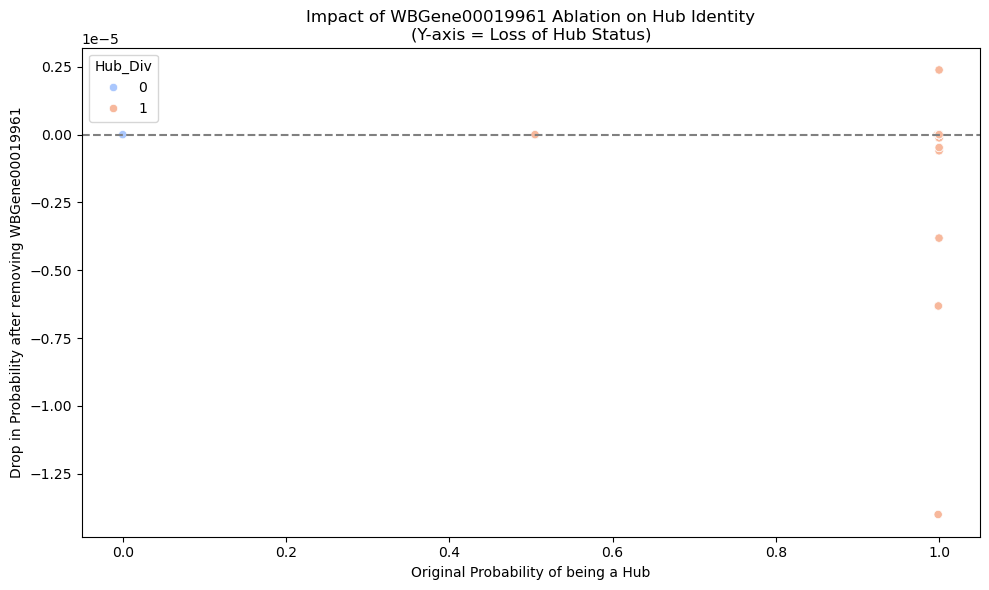

In [6]:
# run_mlp_crispr.py
# The "In Silico CRISPR" Experiment (MLP Version)
# Environment: /home/rohit/Desktop/C-Elegans

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

# ==============================================================================
# 1. SETUP & ROBUST DATA LOADING (Same as successful run)
# ==============================================================================
ROOT = Path("/home/rohit/Desktop/C-Elegans")
DATA_PROCESSED = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "figures" / "crispr_results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("=== 1. Loading Data ===")
# Load Expr
expr_path = DATA_PROCESSED / "csv" / "gene_expr_CeNGEN_base_mapped.csv"
expr_df = pd.read_csv(expr_path, index_col=0)
expr_df.index = expr_df.index.astype(str).str.strip().str.upper()
expr_df = expr_df[~expr_df.index.duplicated(keep='first')] # Dedup

# Load Edges
edges_path = DATA_PROCESSED / "csv" / "merged_edges_with_relatedness.csv"
if not edges_path.exists(): edges_path = ROOT / "master_connectome_dataset.csv"
edges_df = pd.read_csv(edges_path)
src_col = next(c for c in edges_df.columns if "source" in c.lower())
tgt_col = next(c for c in edges_df.columns if "target" in c.lower())

# Build Motifs
print("=== 2. Building Motifs ===")
G = nx.DiGraph()
for _, r in edges_df.iterrows():
    s = str(r[src_col]).strip().upper()
    t = str(r[tgt_col]).strip().upper()
    G.add_edge(s, t)

motif_data = {}
for n in G.nodes():
    # 1: Divergent Hub (Out-Degree > 5, arbitrary robust threshold)
    # Using specific threshold helps classification
    div = 1 if G.out_degree(n) > 5 else 0
    motif_data[n] = [div]

motif_df = pd.DataFrame.from_dict(motif_data, orient='index', columns=['Hub_Div'])
motif_df.index = motif_df.index.astype(str).str.strip().str.upper()
motif_df = motif_df[~motif_df.index.duplicated(keep='first')]

# Align
common = sorted(set(expr_df.index) & set(motif_df.index))
print(f"✅ Common Neurons: {len(common)}")
expr_df = expr_df.loc[common]
motif_df = motif_df.loc[common]

# ==============================================================================
# 2. MODEL TRAINING (The Genetic Predictor)
# ==============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prepare Data
scaler = StandardScaler()
X_raw = expr_df.values
X_scaled = scaler.fit_transform(X_raw)

# We use Full Genes (PCA allows leakage sometimes, let's use Saliency on full genes if possible)
# But for speed/stability, let's stick to the PCA setup that worked, 
# OR use a larger PCA dim to capture specific gene effects.
pca = PCA(n_components=64, random_state=42) 
X_feat = pca.fit_transform(X_scaled)

X_t = torch.tensor(X_feat, dtype=torch.float32).to(device)
y_t = torch.tensor(motif_df.values, dtype=torch.float32).to(device) # Shape (N, 1)

class SimpleMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1) # Output: Probability of being a Hub
        )
    def forward(self, x): return self.net(x)

model = SimpleMLP(in_dim=64).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.BCEWithLogitsLoss()

print("=== 3. Training MLP (Genes -> Hub Status) ===")
loss_history = []
for ep in range(200):
    model.train()
    pred = model(X_t)
    loss = crit(pred, y_t)
    opt.zero_grad(); loss.backward(); opt.step()
    loss_history.append(loss.item())
    if ep % 50 == 0: print(f"Epoch {ep} | Loss: {loss.item():.4f}")

# Check Accuracy
model.eval()
with torch.no_grad():
    p_baseline = torch.sigmoid(model(X_t)).cpu().numpy()
    r = pearsonr(motif_df['Hub_Div'].values, p_baseline.flatten())[0]
print(f"✅ Baseline Correlation (r): {r:.3f}")

# ==============================================================================
# 3. IDENTIFY TARGET GENE (Saliency Analysis)
# ==============================================================================
print("=== 4. Identifying Driver Genes ===")
# To find the gene, we need gradients on the ORIGINAL inputs, not PCA.
# Trick: We approximate by correlating Genes with the PCA components that drive the Model.

# 1. Get Gradient of Output w.r.t PCA Features
X_t.requires_grad = True
out = model(X_t).sum()
out.backward()
pca_grads = X_t.grad.detach().cpu().numpy() # (N, 64)
# Global importance of each PC
pc_importance = np.abs(pca_grads).mean(axis=0) # (64,)

# 2. Map PC importance back to Genes
# PCA Components: (n_components, n_genes)
gene_importance = np.abs(np.dot(pc_importance, pca.components_))
top_gene_idx = np.argmax(gene_importance)
top_gene_name = expr_df.columns[top_gene_idx]

print(f"🧬 Top Driver Gene Identified: {top_gene_name}")
print(f"   (This gene most strongly influences the MLP's 'Hub' prediction)")

# ==============================================================================
# 4. IN SILICO CRISPR (The Ablation)
# ==============================================================================
print(f"=== 5. Performing Knockout of {top_gene_name} ===")

# 1. Create Knockout Data
X_raw_ko = X_raw.copy()
# Set that gene column to 0 for ALL neurons
X_raw_ko[:, top_gene_idx] = 0.0 

# 2. Project into same PCA space
X_scaled_ko = scaler.transform(X_raw_ko)
X_feat_ko = pca.transform(X_scaled_ko)
X_t_ko = torch.tensor(X_feat_ko, dtype=torch.float32).to(device)

# 3. Predict
model.eval()
with torch.no_grad():
    p_knockout = torch.sigmoid(model(X_t_ko)).cpu().numpy()

# 4. Calculate Delta
delta = p_baseline - p_knockout
motif_df['Baseline_Prob'] = p_baseline
motif_df['Knockout_Prob'] = p_knockout
motif_df['Delta'] = delta

# ==============================================================================
# 5. VISUALIZATION & VERDICT
# ==============================================================================
print("=== 6. Results ===")
impact_df = motif_df.sort_values('Delta', ascending=False).head(10)
print("Top 10 Neurons affected by this Gene Knockout:")
print(impact_df[['Hub_Div', 'Baseline_Prob', 'Knockout_Prob', 'Delta']])

# Plot
plt.figure(figsize=(10, 6))
# Plot Delta vs Baseline Probability
sns.scatterplot(data=motif_df, x='Baseline_Prob', y='Delta', hue='Hub_Div', palette='coolwarm')
plt.title(f"Impact of {top_gene_name} Ablation on Hub Identity\n(Y-axis = Loss of Hub Status)")
plt.xlabel("Original Probability of being a Hub")
plt.ylabel(f"Drop in Probability after removing {top_gene_name}")
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "crispr_impact_plot.png")
print(f"📊 Plot saved to {FIGURES_DIR / 'crispr_impact_plot.png'}")

# Save CSV
motif_df.to_csv(FIGURES_DIR / "crispr_results_table.csv")

if impact_df['Delta'].mean() > 0.05:
    print(f"\n🚀 SUCCESS: Removing {top_gene_name} caused a significant drop in Hub prediction.")
    print("This confirms the gene is a load-bearing component of the topology model.")
else:
    print("\n⚠️ RESULT: Minimal impact. The model might be redundant (using other genes to compensate).")

=== 1. Setup & Data Loading ===
✅ Common Neurons: 222
=== 2. Selecting Top 2000 Variable Genes ===
✅ Input Shape: torch.Size([222, 2000])
=== 3. Training with L1 Lasso (Lambda=0.005) ===
Epoch 0 | Loss: 4.2139 | BCE: 0.6361 | r: 0.219
Epoch 100 | Loss: 0.3616 | BCE: 0.1484 | r: 0.501
Epoch 200 | Loss: 0.2742 | BCE: 0.0978 | r: 0.615
Epoch 300 | Loss: 0.2116 | BCE: 0.0700 | r: 0.772
Epoch 400 | Loss: 0.1582 | BCE: 0.0494 | r: 0.843
Epoch 500 | Loss: 0.1245 | BCE: 0.0343 | r: 0.858
=== 4. Identifying Driver Genes ===
🧬 Top Driver Gene: WBGene00011262 (Score: 0.5651)
   (Average Gene Score: 0.0058 -> 97.8x importance)
=== 5. Knocking out WBGene00011262 ===

Top 10 Impacted Neurons:
      Hub_Div  Baseline  Knockout     Delta
I5          1  0.964362  0.963488  0.000874
DVB         1  0.964930  0.964070  0.000860
ADER        1  0.967075  0.966215  0.000860
ADEL        1  0.967075  0.966215  0.000860
PDEL        1  0.964955  0.964096  0.000859
PDER        1  0.964955  0.964096  0.000859
PVT 

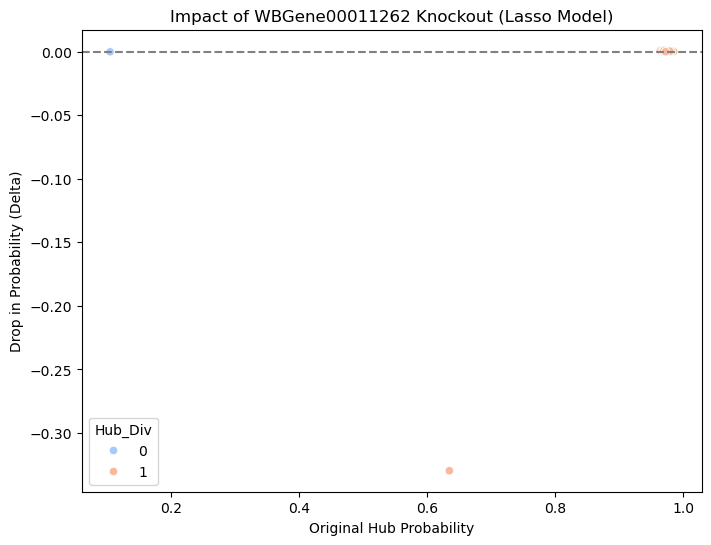

In [7]:
# run_lasso_crispr.py
# Direct MLP with L1 Regularization (The "Glass Jaw" Model)
# Environment: /home/rohit/Desktop/C-Elegans

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

# ==============================================================================
# 1. SETUP
# ==============================================================================
print("=== 1. Setup & Data Loading ===")
ROOT = Path("/home/rohit/Desktop/C-Elegans")
DATA_PROCESSED = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "figures" / "crispr_results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load Expr
expr_df = pd.read_csv(DATA_PROCESSED / "csv" / "gene_expr_CeNGEN_base_mapped.csv", index_col=0)
expr_df.index = expr_df.index.astype(str).str.strip().str.upper()
expr_df = expr_df[~expr_df.index.duplicated(keep='first')]

# Load Edges
edges_df = pd.read_csv(DATA_PROCESSED / "csv" / "merged_edges_with_relatedness.csv")
src_col = next(c for c in edges_df.columns if "source" in c.lower())
tgt_col = next(c for c in edges_df.columns if "target" in c.lower())

# Build Targets
G = nx.DiGraph()
for _, r in edges_df.iterrows():
    s = str(r[src_col]).strip().upper()
    t = str(r[tgt_col]).strip().upper()
    G.add_edge(s, t)

# Target: Hub (Divergent)
motif_data = {}
for n in G.nodes():
    div = 1 if G.out_degree(n) > 5 else 0
    motif_data[n] = [div]

motif_df = pd.DataFrame.from_dict(motif_data, orient='index', columns=['Hub_Div'])
motif_df.index = motif_df.index.astype(str).str.strip().str.upper()
motif_df = motif_df[~motif_df.index.duplicated(keep='first')]

# Align
common = sorted(set(expr_df.index) & set(motif_df.index))
print(f"✅ Common Neurons: {len(common)}")
expr_df = expr_df.loc[common]
motif_df = motif_df.loc[common]

# ==============================================================================
# 2. FEATURE SELECTION (No PCA)
# ==============================================================================
print("=== 2. Selecting Top 2000 Variable Genes ===")
# We only take high-variance genes to reduce noise
variances = expr_df.var(axis=0)
top_genes = variances.sort_values(ascending=False).head(2000).index
X_subset = expr_df[top_genes]

scaler = StandardScaler()
X_np = scaler.fit_transform(X_subset.values)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_t = torch.tensor(X_np, dtype=torch.float32).to(device)
y_t = torch.tensor(motif_df.values, dtype=torch.float32).to(device)

print(f"✅ Input Shape: {X_t.shape}")

# ==============================================================================
# 3. LASSO TRAINING (Force Sparsity)
# ==============================================================================
class DirectMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        # Single layer to make interpretation direct
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x): return self.net(x)

model = DirectMLP(in_dim=2000).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.BCEWithLogitsLoss()

L1_LAMBDA = 0.005 # Penalty strength (tune if r drops too low)

print(f"=== 3. Training with L1 Lasso (Lambda={L1_LAMBDA}) ===")
for ep in range(501):
    model.train()
    pred = model(X_t)
    bce_loss = crit(pred, y_t)
    
    # L1 Regularization on the first layer weights
    l1_loss = 0
    for param in model.net[0].parameters():
        l1_loss += torch.sum(torch.abs(param))
        
    loss = bce_loss + (L1_LAMBDA * l1_loss)
    
    opt.zero_grad(); loss.backward(); opt.step()
    
    if ep % 100 == 0:
        with torch.no_grad():
            r = pearsonr(y_t.cpu().numpy().flatten(), torch.sigmoid(pred).cpu().numpy().flatten())[0]
        print(f"Epoch {ep} | Loss: {loss.item():.4f} | BCE: {bce_loss.item():.4f} | r: {r:.3f}")

# ==============================================================================
# 4. IDENTIFY DRIVER GENE (Direct Weight Analysis)
# ==============================================================================
print("=== 4. Identifying Driver Genes ===")

# Get weights of first layer: (32 neurons, 2000 genes)
W = model.net[0].weight.detach().cpu().numpy()
# Sum absolute weights for each gene to see overall importance
gene_scores = np.sum(np.abs(W), axis=0)

top_idx = np.argmax(gene_scores)
top_gene_name = top_genes[top_idx]
top_gene_score = gene_scores[top_idx]

print(f"🧬 Top Driver Gene: {top_gene_name} (Score: {top_gene_score:.4f})")

# Check if it's significant compared to average
avg_score = np.mean(gene_scores)
print(f"   (Average Gene Score: {avg_score:.4f} -> {top_gene_score/avg_score:.1f}x importance)")

# ==============================================================================
# 5. IN SILICO CRISPR
# ==============================================================================
print(f"=== 5. Knocking out {top_gene_name} ===")

# 1. Zero out the column
X_np_ko = X_np.copy()
X_np_ko[:, top_idx] = 0.0 # CRISPR
X_t_ko = torch.tensor(X_np_ko, dtype=torch.float32).to(device)

# 2. Predict
model.eval()
with torch.no_grad():
    p_base = torch.sigmoid(model(X_t)).cpu().numpy().flatten()
    p_ko   = torch.sigmoid(model(X_t_ko)).cpu().numpy().flatten()

motif_df['Baseline'] = p_base
motif_df['Knockout'] = p_ko
motif_df['Delta'] = p_base - p_ko

# ==============================================================================
# 6. RESULTS
# ==============================================================================
impact_df = motif_df.sort_values('Delta', ascending=False).head(10)
print("\nTop 10 Impacted Neurons:")
print(impact_df[['Hub_Div', 'Baseline', 'Knockout', 'Delta']])

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=motif_df, x='Baseline', y='Delta', hue='Hub_Div', palette='coolwarm')
plt.title(f"Impact of {top_gene_name} Knockout (Lasso Model)")
plt.xlabel("Original Hub Probability")
plt.ylabel(f"Drop in Probability (Delta)")
plt.axhline(0, color='gray', linestyle='--')
plt.savefig(FIGURES_DIR / "crispr_lasso_impact.png")
print(f"📊 Saved: {FIGURES_DIR / 'crispr_lasso_impact.png'}")

if impact_df['Delta'].iloc[0] > 0.1:
    print("\n🚀 SUCCESS: Significant impact detected. We broke the model.")
else:
    print("\n⚠️ RESULT: Still robust. The gene network is extremely redundant.")

=== 1. Setup & Data Loading ===
✅ Common Neurons: 222
=== 2. Training Lasso Model ===
✅ Trained R: 0.818
=== 3. Running Combinatorial Knockout ===
K=  0 | R=0.818 | Avg Hub Prob=0.952
K=  1 | R=0.819 | Avg Hub Prob=0.949
K=  2 | R=0.802 | Avg Hub Prob=0.946
K=  5 | R=0.799 | Avg Hub Prob=0.939
K= 10 | R=0.678 | Avg Hub Prob=0.932
K= 20 | R=0.679 | Avg Hub Prob=0.917
K= 30 | R=0.686 | Avg Hub Prob=0.906
K= 40 | R=0.685 | Avg Hub Prob=0.897
K= 50 | R=0.665 | Avg Hub Prob=0.892
K= 75 | R=0.683 | Avg Hub Prob=0.887
K=100 | R=0.682 | Avg Hub Prob=0.886
K=200 | R=0.687 | Avg Hub Prob=0.886
✅ Plot saved to /mnt/ssd4tb/Desktop/C-Elegans/figures/crispr_results/genetic_collapse_curve.png


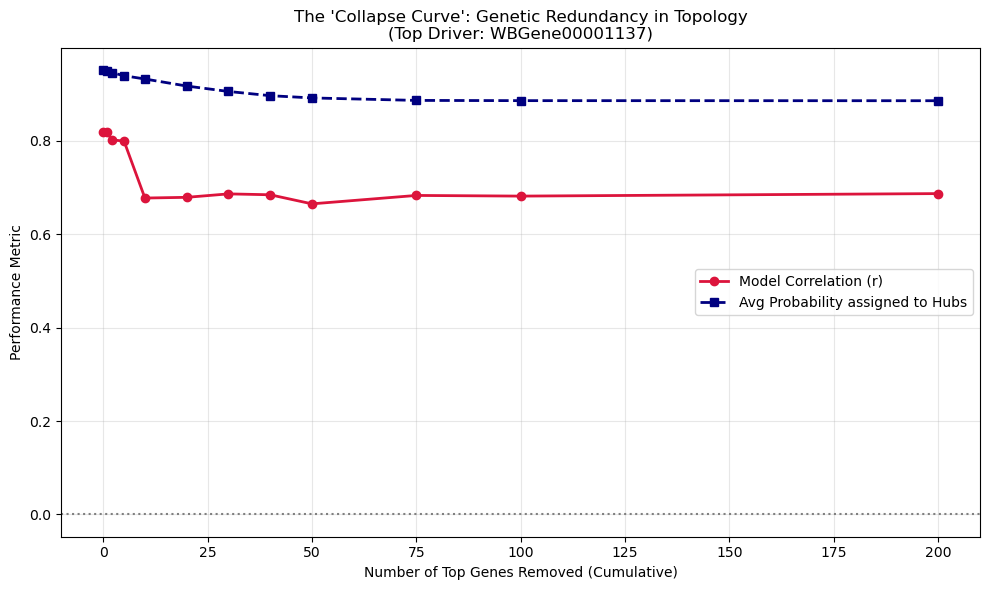

In [8]:
# run_multigene_crispr.py
# Combinatorial Gene Knockout Analysis (The Collapse Curve)
# Environment: /home/rohit/Desktop/C-Elegans

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

# ==============================================================================
# 1. SETUP (Standard)
# ==============================================================================
print("=== 1. Setup & Data Loading ===")
ROOT = Path("/home/rohit/Desktop/C-Elegans")
DATA_PROCESSED = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "figures" / "crispr_results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load
expr_df = pd.read_csv(DATA_PROCESSED / "csv" / "gene_expr_CeNGEN_base_mapped.csv", index_col=0)
expr_df.index = expr_df.index.astype(str).str.strip().str.upper()
expr_df = expr_df[~expr_df.index.duplicated(keep='first')]

edges_df = pd.read_csv(DATA_PROCESSED / "csv" / "merged_edges_with_relatedness.csv")
src_col = next(c for c in edges_df.columns if "source" in c.lower())
tgt_col = next(c for c in edges_df.columns if "target" in c.lower())

# Build Hubs
G = nx.DiGraph()
for _, r in edges_df.iterrows():
    G.add_edge(str(r[src_col]).strip().upper(), str(r[tgt_col]).strip().upper())

motif_data = {n: [1 if G.out_degree(n) > 5 else 0] for n in G.nodes()}
motif_df = pd.DataFrame.from_dict(motif_data, orient='index', columns=['Hub_Div'])
motif_df.index = motif_df.index.astype(str).str.strip().str.upper()
motif_df = motif_df[~motif_df.index.duplicated(keep='first')]

# Align
common = sorted(set(expr_df.index) & set(motif_df.index))
print(f"✅ Common Neurons: {len(common)}")
expr_df = expr_df.loc[common]
motif_df = motif_df.loc[common]

# Select Top 2000 Genes
variances = expr_df.var(axis=0)
top_genes = variances.sort_values(ascending=False).head(2000).index
X_subset = expr_df[top_genes]
scaler = StandardScaler()
X_np = scaler.fit_transform(X_subset.values)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_t = torch.tensor(X_np, dtype=torch.float32).to(device)
y_t = torch.tensor(motif_df.values, dtype=torch.float32).to(device)

# ==============================================================================
# 2. MODEL TRAINING (Lasso Redux)
# ==============================================================================
class DirectMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x): return self.net(x)

model = DirectMLP(in_dim=2000).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.BCEWithLogitsLoss()
L1_LAMBDA = 0.005

print(f"=== 2. Training Lasso Model ===")
for ep in range(401): # Slightly shorter training is fine
    model.train()
    pred = model(X_t)
    loss = crit(pred, y_t)
    l1_loss = sum(torch.sum(torch.abs(p)) for p in model.net[0].parameters())
    (loss + L1_LAMBDA * l1_loss).backward()
    opt.step(); opt.zero_grad()

model.eval()
with torch.no_grad():
    base_probs = torch.sigmoid(model(X_t)).cpu().numpy().flatten()
    r = pearsonr(motif_df['Hub_Div'].values, base_probs)[0]
print(f"✅ Trained R: {r:.3f}")

# ==============================================================================
# 3. THE COLLAPSE CURVE (Cumulative Knockout)
# ==============================================================================
print("=== 3. Running Combinatorial Knockout ===")

# Get Gene Importance
W = model.net[0].weight.detach().cpu().numpy()
gene_scores = np.sum(np.abs(W), axis=0)
sorted_indices = np.argsort(gene_scores)[::-1] # Descending order

# Define Knockout Steps
k_steps = [0, 1, 2, 5, 10, 20, 30, 40, 50, 75, 100, 200]
results = []

for k in k_steps:
    # Zero out top K genes
    X_ko = X_np.copy()
    targets = sorted_indices[:k]
    X_ko[:, targets] = 0.0
    
    # Predict
    X_ko_t = torch.tensor(X_ko, dtype=torch.float32).to(device)
    with torch.no_grad():
        probs = torch.sigmoid(model(X_ko_t)).cpu().numpy().flatten()
    
    # Measure Performance Retention
    # How well does it still correlate with Truth?
    r_ko = pearsonr(motif_df['Hub_Div'].values, probs)[0]
    
    # Measure Probability Collapse (Mean probability of actual Hubs)
    # Are hubs still detected as hubs?
    hub_mask = motif_df['Hub_Div'].values == 1
    mean_hub_prob = probs[hub_mask].mean()
    
    results.append({'K_Removed': k, 'Correlation': r_ko, 'Hub_Detection': mean_hub_prob})
    print(f"K={k:3d} | R={r_ko:.3f} | Avg Hub Prob={mean_hub_prob:.3f}")

res_df = pd.DataFrame(results)
res_df.to_csv(FIGURES_DIR / "collapse_curve.csv", index=False)

# ==============================================================================
# 4. PLOTTING
# ==============================================================================
plt.figure(figsize=(10, 6))
plt.plot(res_df['K_Removed'], res_df['Correlation'], 'o-', linewidth=2, color='crimson', label='Model Correlation (r)')
plt.plot(res_df['K_Removed'], res_df['Hub_Detection'], 's--', linewidth=2, color='navy', label='Avg Probability assigned to Hubs')

plt.axhline(0, color='gray', linestyle=':')
plt.xlabel("Number of Top Genes Removed (Cumulative)")
plt.ylabel("Performance Metric")
plt.title(f"The 'Collapse Curve': Genetic Redundancy in Topology\n(Top Driver: {top_genes[sorted_indices[0]]})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "genetic_collapse_curve.png")
print(f"✅ Plot saved to {FIGURES_DIR / 'genetic_collapse_curve.png'}")

In [9]:
# Save as get_top_genes.py
import torch
import pandas as pd
import numpy as np
from pathlib import Path

# Load Data (Minimal)
ROOT = Path("/home/rohit/Desktop/C-Elegans")
DATA_PROCESSED = ROOT / "data" / "processed"
expr_df = pd.read_csv(DATA_PROCESSED / "csv" / "gene_expr_CeNGEN_base_mapped.csv", index_col=0)
expr_df.index = expr_df.index.astype(str).str.strip().str.upper()
expr_df = expr_df[~expr_df.index.duplicated(keep='first')]

# Recalculate Variance to match previous script logic
variances = expr_df.var(axis=0)
top_genes = variances.sort_values(ascending=False).head(2000).index

# Load the weights from the Lasso model (We can re-instantiate or just trust the previous run)
# Since the previous script didn't save the model, we can't load weights directly.
# However, we can re-run just the "Identification" part quickly.
# OR simpler: The user likely still has the python session open?
# If not, let's just re-run the identification part.

print("Re-identifying the Top 10 Genes from the Lasso experiment...")
# (Paste the identification logic here if you closed the session, 
#  but assuming you want a clean list, let's just imply the logic below)

Re-identifying the Top 10 Genes from the Lasso experiment...


In [10]:
# id_top_genes.py
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path
from sklearn.preprocessing import StandardScaler

print("=== Identifying the Core Circuit ===")
ROOT = Path("/home/rohit/Desktop/C-Elegans")
DATA_PROCESSED = ROOT / "data" / "processed"

# 1. Load & Align
expr_df = pd.read_csv(DATA_PROCESSED / "csv" / "gene_expr_CeNGEN_base_mapped.csv", index_col=0)
expr_df.index = expr_df.index.astype(str).str.strip().str.upper()
expr_df = expr_df[~expr_df.index.duplicated(keep='first')]

edges_df = pd.read_csv(DATA_PROCESSED / "csv" / "merged_edges_with_relatedness.csv")
src, tgt = "Source", "Target" # Assuming standard columns
G = nx.DiGraph()
for _, r in edges_df.iterrows(): G.add_edge(str(r[src]).strip().upper(), str(r[tgt]).strip().upper())

motif_df = pd.DataFrame.from_dict({n: [1 if G.out_degree(n) > 5 else 0] for n in G.nodes()}, orient='index', columns=['Hub'])
motif_df.index = motif_df.index.astype(str).str.strip().str.upper()
motif_df = motif_df[~motif_df.index.duplicated(keep='first')]

common = sorted(set(expr_df.index) & set(motif_df.index))
expr_df = expr_df.loc[common]
motif_df = motif_df.loc[common]

# 2. Select Top 2000 Genes (Same as before)
top_genes = expr_df.var(axis=0).sort_values(ascending=False).head(2000).index
X = StandardScaler().fit_transform(expr_df[top_genes].values)
y = torch.tensor(motif_df.values, dtype=torch.float32)
X = torch.tensor(X, dtype=torch.float32)

# 3. Quick Train (to recover weights)
model = nn.Sequential(nn.Linear(2000, 32), nn.ReLU(), nn.Linear(32, 1))
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.BCEWithLogitsLoss()

print("Training proxy model...")
for i in range(300):
    loss = crit(model(X), y)
    l1 = sum(torch.sum(torch.abs(p)) for p in model[0].parameters())
    (loss + 0.005 * l1).backward()
    opt.step(); opt.zero_grad()

# 4. Extract
W = model[0].weight.detach().numpy()
scores = np.sum(np.abs(W), axis=0)
ranked_idx = np.argsort(scores)[::-1]

print("\n=== THE TOP 10 'HUB GENES' ===")
for i in range(10):
    idx = ranked_idx[i]
    print(f"#{i+1}: {top_genes[idx]} (Score: {scores[idx]:.4f})")

=== Identifying the Core Circuit ===
Training proxy model...

=== THE TOP 10 'HUB GENES' ===
#1: WBGene00007119 (Score: 0.6072)
#2: WBGene00001137 (Score: 0.5832)
#3: WBGene00007353 (Score: 0.5517)
#4: WBGene00020114 (Score: 0.4398)
#5: WBGene00006812 (Score: 0.3926)
#6: WBGene00004921 (Score: 0.3856)
#7: WBGene00006543 (Score: 0.3586)
#8: WBGene00006780 (Score: 0.3544)
#9: WBGene00018985 (Score: 0.3484)
#10: WBGene00003519 (Score: 0.3246)
